# TRIS × limTOD: conventions, data, forward model, and map-making

The public [TRIS archive](https://lambda.gsfc.nasa.gov/product/tris/tris_prod_table.html)
ships **final beam-convolved profiles**, not raw TOD. This walkthrough covers what it
takes to use them with limTOD:

1. **Conventions** — what TRIS states, what limTOD expects, and a numerical check that
   the translation in `limTOD.tris` is right.
2. **Data and beam** — the four products, and why the beam has to be built from the
   archive's own cuts rather than a Gaussian.
3. **Real GSM comparison** — forward-model GSM2008 and GSM2016 through limTOD and
   compare with the absolutely-calibrated rings.
4. **Map-making** — prior-regularized reconstruction, showing prior, estimate and
   posterior uncertainty.

Everything runs offline. It needs the gitignored `downloads/TRIS/` copy of the archive
and a pyGDSM data cache (both already present if you have run this repo's TRIS work).

In [1]:
%matplotlib inline
import os
os.environ["TQDM_DISABLE"] = "1"   # limTOD's per-sample progress bars

import warnings
from pathlib import Path

import healpy as hp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "figure.facecolor": "white"})

ARCHIVE = Path("../../downloads/TRIS")
assert ARCHIVE.exists(), f"put the four LAMBDA TRIS text files in {ARCHIVE.resolve()}"
sorted(p.name for p in ARCHIVE.glob("*.txt"))

['TRIS_Beam_Profile.txt',
 'TRIS_absolute_2500MHz.txt',
 'TRIS_absolute_600.txt',
 'TRIS_absolute_820.txt']

---
## Part 1 — TRIS conventions vs limTOD conventions

### What each side says

| Quantity | TRIS archive states | limTOD expects | `limTOD.tris` translation |
|---|---|---|---|
| Pointing | antenna parked at zenith | `az`, `el`, `LST`, `lat` per sample | `az=0`, `el=90`, `LST=RA label`, `lat=42°26′` |
| Sample coordinate | RA label `hh mm` | `LST_deg` | RA → LST **exactly** (zenith ⇒ hour angle 0) |
| Beam pole | boresight | HEALPix north pole | same |
| Beam azimuth | E- and H-plane cuts | `φ=0` → increasing elevation, `φ=90°` → increasing azimuth | E at `φ=0/180`, H at `φ=90/270` |
| Beam roll | "E-plane tilted 7° **east** of the meridian" | `selfrot` about boresight | `selfrot = −7°` |
| Temperature | "Sky Brightness Temperature (K)" | scalar K map | Rayleigh–Jeans, **CMB monopole included** |
| Map ordering | — | HEALPix RING, equatorial | same |

Two of these rows are *not* in any archive header — the sign of the roll and the
temperature convention. Both are checked below rather than assumed.

### The `limTOD.tris` package

In [2]:
import limTOD.tris as tris

groups = {
    "archive readers": ["read_tris_ring", "read_tris_point_set", "read_tris_beam_cuts",
                        "parse_tris_ra", "TRISRing", "TRISPointSet",
                        "TRISPrincipalPlaneCuts", "AsymmetricUncertainty"],
    "temperature convention": ["cmb_monopole_rj_k", "to_tris_temperature_convention",
                               "galactic_spectral_index", "CMB_T0_K"],
    "beam": ["tris_cut_beam_map", "tris_cut_beam_func", "tris_cut_beam_response",
             "tris_horizon_mask", "approximate_tris_gaussian_beam_map", "tris_beam_func"],
    "geometry": ["tris_zenith_geometry", "TRISZenithGeometry", "TRIS_SITE_LATITUDE_DEG",
                 "TRIS_DECLINATION_LABEL_DEG", "TRIS_E_PLANE_EAST_OF_MERIDIAN_DEG"],
    "noise + inference": ["TRISNoiseModel", "fit_tris_linear_model",
                          "build_tris_fourier_design", "TRISLinearFit",
                          "TRISRankDiagnostic"],
    "map-making": ["build_tris_mapmaking_inputs", "TRISMapMakingInputs",
                   "tris_ring_pixels", "tris_prior_from_template"],
}
for name, members in groups.items():
    print(f"{name:24s} {', '.join(members)}")
print()
print("everything in __all__ is covered:", set(sum(groups.values(), [])) == set(tris.__all__))

archive readers          read_tris_ring, read_tris_point_set, read_tris_beam_cuts, parse_tris_ra, TRISRing, TRISPointSet, TRISPrincipalPlaneCuts, AsymmetricUncertainty
temperature convention   cmb_monopole_rj_k, to_tris_temperature_convention, galactic_spectral_index, CMB_T0_K
beam                     tris_cut_beam_map, tris_cut_beam_func, tris_cut_beam_response, tris_horizon_mask, approximate_tris_gaussian_beam_map, tris_beam_func
geometry                 tris_zenith_geometry, TRISZenithGeometry, TRIS_SITE_LATITUDE_DEG, TRIS_DECLINATION_LABEL_DEG, TRIS_E_PLANE_EAST_OF_MERIDIAN_DEG
noise + inference        TRISNoiseModel, fit_tris_linear_model, build_tris_fourier_design, TRISLinearFit, TRISRankDiagnostic
map-making               build_tris_mapmaking_inputs, TRISMapMakingInputs, tris_ring_pixels, tris_prior_from_template

everything in __all__ is covered: True


### Check 1 — where does the boresight land?

For a zenith park the boresight must sit at `RA = LST`, `dec = latitude`, at every LST.
We push a narrow marker through limTOD's own pointing chain and read off where it lands.

In [3]:
from limTOD.simulator import pointing_beam_in_eq_sys
from limTOD.tris import TRIS_SITE_LATITUDE_DEG, tris_zenith_geometry

NSIDE_PROBE = 256

def _marker_alm(phi_deg, theta_deg, sigma_deg=1.0):
    target = np.asarray(hp.ang2vec(np.deg2rad(theta_deg), np.deg2rad(phi_deg))).ravel()
    theta, phi = hp.pix2ang(NSIDE_PROBE, np.arange(hp.nside2npix(NSIDE_PROBE)))
    sep = np.arccos(np.clip(np.asarray(hp.ang2vec(theta, phi)) @ target, -1, 1))
    return hp.map2alm(np.exp(-0.5 * (sep / np.deg2rad(sigma_deg)) ** 2), lmax=2 * NSIDE_PROBE)

def land(phi_deg, theta_deg, lst_deg, selfrot_deg, lat_deg=TRIS_SITE_LATITUDE_DEG):
    # returns (RA, dec) in degrees where a beam-frame direction ends up
    pointed = pointing_beam_in_eq_sys(
        _marker_alm(phi_deg, theta_deg), LST_deg=lst_deg, lat_deg=lat_deg,
        azimuth_deg=0.0, elevation_deg=90.0, selfrot_deg=selfrot_deg,
        nside=NSIDE_PROBE, normalize=False)
    bright = pointed > 0.05 * pointed.max()   # wide cut => unbiased centroid
    vec = (np.asarray(hp.pix2vec(NSIDE_PROBE, np.where(bright)[0])) * pointed[bright]).sum(axis=1)
    theta, phi = hp.vec2ang(vec / np.linalg.norm(vec))
    return float(np.rad2deg(phi[0])), float(90 - np.rad2deg(theta[0]))

print(f"{'LST':>7} {'RA found':>10} {'dec found':>10}   (want RA=LST, dec={TRIS_SITE_LATITUDE_DEG:.3f})")
for lst in (0.0, 31.0, 137.0, 259.0):
    ra, dec = land(0.0, 0.0, lst, selfrot_deg=-7.0)
    print(f"{lst:7.1f} {ra:10.3f} {dec:10.3f}")

    LST   RA found  dec found   (want RA=LST, dec=42.433)


    0.0      0.000     42.430


   31.0     31.002     42.433


  137.0    136.998     42.434


  259.0    258.998     42.434


### Check 2 — does `selfrot = −7°` really tilt the E plane 7° **east**?

Position angle is measured east of north at the boresight. With no roll the E plane
should lie exactly on the meridian (PA 180°/0°) and the H plane exactly east–west.
With `selfrot = −7` both should rotate by **+7°**.

In [4]:
def position_angle(ra, dec, ra0, dec0):
    dra = np.deg2rad((ra - ra0 + 180) % 360 - 180)
    d0, d = np.deg2rad(dec0), np.deg2rad(dec)
    return float(np.rad2deg(np.arctan2(np.sin(dra) * np.cos(d),
                 np.cos(d0) * np.sin(d) - np.sin(d0) * np.cos(d) * np.cos(dra))) % 360)

LST = 60.0
rows = []
for label, phi in [("E  (φ=0)", 0.0), ("E  (φ=180)", 180.0), ("H  (φ=90)", 90.0), ("H  (φ=270)", 270.0)]:
    pas = []
    for selfrot in (0.0, -7.0):
        ra, dec = land(phi, 12.0, LST, selfrot)
        pas.append(position_angle(ra, dec, LST, TRIS_SITE_LATITUDE_DEG))
    rows.append((label, pas[0], pas[1], ((pas[1] - pas[0] + 180) % 360) - 180))

print(f"{'beam axis':<12}{'PA(selfrot=0)':>15}{'PA(selfrot=-7)':>16}{'shift':>9}")
for label, a, b, d in rows:
    print(f"{label:<12}{a:15.2f}{b:16.2f}{d:+9.2f}")
print("\nE is the NARROW plane (19.2° vs 23.4°), so the TRIS beam is")
print("narrow in declination and wide in right ascension.")

beam axis     PA(selfrot=0)  PA(selfrot=-7)    shift
E  (φ=0)             179.99          187.00    +7.01
E  (φ=180)             0.00            7.00    +7.00
H  (φ=90)             90.01           97.01    +7.00
H  (φ=270)           270.00          276.99    +6.99

E is the NARROW plane (19.2° vs 23.4°), so the TRIS beam is
narrow in declination and wide in right ascension.


The roll comes out `+7°` east on both axes, matching the archive note
`# NOTE2 = the E-plane is tilted 7 degrees Eastwards with respect to the meridian`.

`tris_zenith_geometry` owns this orientation — never pre-rotate the beam map as well.

In [5]:
from limTOD.tris import read_tris_ring

ring600 = read_tris_ring(ARCHIVE / "TRIS_absolute_600.txt")
geometry = tris_zenith_geometry(ring600.ra_deg)

print("TRISZenithGeometry")
print(f"  samples           {geometry.lst_deg.size}")
print(f"  LST  [deg]        {geometry.lst_deg[:4]} ...")
print(f"  azimuth [deg]     {np.unique(geometry.azimuth_deg)}  (degenerate at zenith)")
print(f"  elevation [deg]   {np.unique(geometry.elevation_deg)}")
print(f"  selfrot [deg]     {np.unique(geometry.selfrot_deg)}")
print(f"  latitude [deg]    {geometry.latitude_deg:.4f}   -> boresight dec {geometry.boresight_dec_deg:.4f}")

TRISZenithGeometry
  samples           120
  LST  [deg]        [0. 3. 6. 9.] ...
  azimuth [deg]     [0.]  (degenerate at zenith)
  elevation [deg]   [90.]
  selfrot [deg]     [-7.]
  latitude [deg]    42.4333   -> boresight dec 42.4333


---
## Part 2 — The TRIS data and beam

### The four products

In [6]:
from limTOD.tris import read_tris_beam_cuts, read_tris_point_set

ring820 = read_tris_ring(ARCHIVE / "TRIS_absolute_820.txt")
points  = read_tris_point_set(ARCHIVE / "TRIS_absolute_2500MHz.txt")
cuts    = read_tris_beam_cuts(ARCHIVE / "TRIS_Beam_Profile.txt")

for name, obj in (("600 MHz ring", ring600), ("820 MHz ring", ring820), ("2.5 GHz points", points)):
    print(f"{name:16s} n={obj.ra_deg.size:3d}  nu_eff={obj.effective_frequency_mhz:7.1f} MHz  "
          f"T=[{obj.temperature_k.min():6.3f}, {obj.temperature_k.max():7.3f}] K  "
          f"zero level={obj.zero_level_uncertainty_k}")
print(f"{'beam cuts':16s} n={cuts.angle_deg.size:3d}  angles 0 -> {cuts.angle_deg.max():.0f} deg, "
      f"deepest {min(cuts.e_plane_db.min(), cuts.h_plane_db.min()):.0f} dB, anti-boresight {cuts.e_plane_db[-1]:.0f} dB")

print("\nTwo details that a careless reader would destroy:")
print("  RA spacings present:", sorted(set(np.round(np.diff(ring600.ra_deg), 9))),
      "deg  <- NOT a uniform 3 deg grid")
print("  rows with zero statistical error:",
      int((ring600.statistical_uncertainty_k == 0).sum()), "(600) and",
      int((ring820.statistical_uncertainty_k == 0).sum()), "(820)",
      " -> an uncertainty floor is mandatory")

600 MHz ring     n=120  nu_eff=  600.5 MHz  T=[ 9.390,  28.193] K  zero level=0.066
820 MHz ring     n=120  nu_eff=  817.8 MHz  T=[ 5.357,  13.574] K  zero level=AsymmetricUncertainty(positive_k=0.43, negative_k=0.3)
2.5 GHz points   n=  6  nu_eff= 2427.8 MHz  T=[ 2.329,   2.886] K  zero level=0.284
beam cuts        n= 55  angles 0 -> 176 deg, deepest -60 dB, anti-boresight -48 dB

Two details that a careless reader would destroy:
  RA spacings present: [np.float64(2.75), np.float64(3.0), np.float64(3.25)] deg  <- NOT a uniform 3 deg grid
  rows with zero statistical error: 1 (600) and 1 (820)  -> an uncertainty floor is mandatory


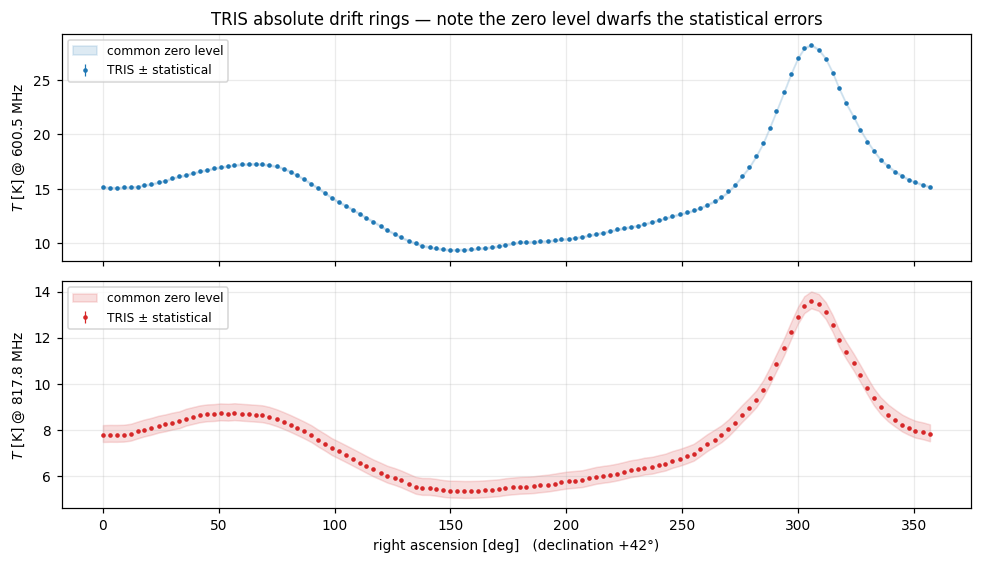

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5.2), sharex=True)
for ax, ring, colour in ((axes[0], ring600, "tab:blue"), (axes[1], ring820, "tab:red")):
    ax.errorbar(ring.ra_deg, ring.temperature_k, yerr=ring.statistical_uncertainty_k,
                fmt=".", ms=4, lw=0.8, color=colour, label="TRIS ± statistical")
    zero = ring.zero_level_uncertainty_k
    lo, hi = (zero, zero) if np.isscalar(zero) else (zero.negative_k, zero.positive_k)
    ax.fill_between(ring.ra_deg, ring.temperature_k - lo, ring.temperature_k + hi,
                    color=colour, alpha=0.15, label="common zero level")
    ax.set_ylabel(f"$T$ [K] @ {ring.effective_frequency_mhz:.1f} MHz")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.25)
axes[1].set_xlabel("right ascension [deg]   (declination +42°)")
axes[0].set_title("TRIS absolute drift rings — note the zero level dwarfs the statistical errors")
fig.tight_layout()

### The temperature convention, settled from the data

The archive never says Rayleigh–Jeans vs thermodynamic, nor whether the CMB monopole is
included. The two rings share an RA grid, so the Galactic spectral index between them is
a clean per-sample discriminator: only one treatment gives synchrotron.

In [8]:
from limTOD.tris import CMB_T0_K, cmb_monopole_rj_k, galactic_spectral_index

nu6, nu8 = ring600.effective_frequency_mhz, ring820.effective_frequency_mhz
assert np.allclose(ring600.ra_deg, ring820.ra_deg)

with_cmb = np.log(ring600.temperature_k / ring820.temperature_k) / np.log(nu6 / nu8)
without  = galactic_spectral_index(ring600.temperature_k, nu6, ring820.temperature_k, nu8)

print(f"CMB monopole: thermodynamic {CMB_T0_K:.5f} K")
print(f"  Rayleigh-Jeans equivalent: {cmb_monopole_rj_k(nu6):.4f} K @ {nu6} MHz, "
      f"{cmb_monopole_rj_k(nu8):.4f} K @ {nu8} MHz")
print(f"  RJ-vs-thermodynamic gap {CMB_T0_K - cmb_monopole_rj_k(nu6):.4f} K "
      f"exceeds the median statistical error {np.median(ring600.statistical_uncertainty_k):.4f} K\n")
print(f"{'treatment':<28}{'min':>8}{'median':>9}{'max':>8}")
print(f"{'CMB monopole left in':<28}{with_cmb.min():8.2f}{np.median(with_cmb):9.2f}{with_cmb.max():8.2f}")
print(f"{'CMB monopole removed (RJ)':<28}{without.min():8.2f}{np.median(without):9.2f}{without.max():8.2f}")
print("\nSynchrotron is -2.5..-3.1 and flattens toward the plane. Only the second row is")
print("physical => TRIS temperatures are Rayleigh-Jeans and INCLUDE the CMB monopole.")

CMB monopole: thermodynamic 2.72548 K
  Rayleigh-Jeans equivalent: 2.7111 K @ 600.5 MHz, 2.7059 K @ 817.8 MHz
  RJ-vs-thermodynamic gap 0.0144 K exceeds the median statistical error 0.0100 K

treatment                        min   median     max
CMB monopole left in           -2.39    -2.10   -1.81
CMB monopole removed (RJ)      -3.12    -2.91   -2.63

Synchrotron is -2.5..-3.1 and flattens toward the plane. Only the second row is
physical => TRIS temperatures are Rayleigh-Jeans and INCLUDE the CMB monopole.


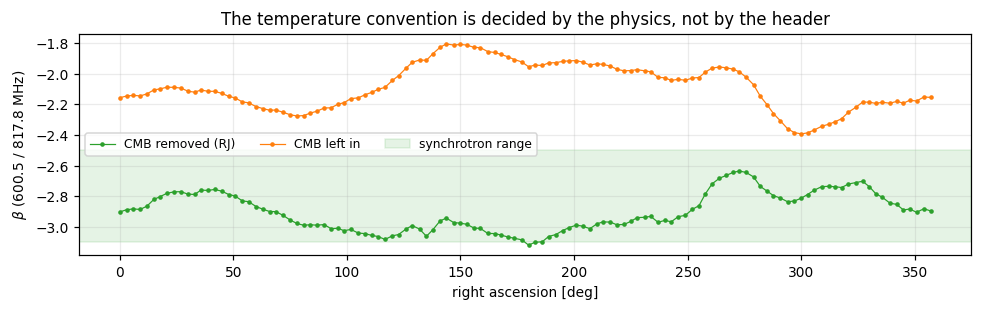

In [9]:
fig, ax = plt.subplots(figsize=(9, 2.9))
ax.plot(ring600.ra_deg, without, ".-", ms=4, lw=0.8, color="tab:green", label="CMB removed (RJ)")
ax.plot(ring600.ra_deg, with_cmb, ".-", ms=4, lw=0.8, color="tab:orange", label="CMB left in")
ax.axhspan(-3.1, -2.5, color="tab:green", alpha=0.12, label="synchrotron range")
ax.set_xlabel("right ascension [deg]"); ax.set_ylabel(r"$\beta$ (600.5 / 817.8 MHz)")
ax.legend(fontsize=8, ncol=3); ax.grid(alpha=0.25)
ax.set_title("The temperature convention is decided by the physics, not by the header")
fig.tight_layout()

### The beam: archive cuts vs the Gaussian

`TRIS_Beam_Profile.txt` tabulates **both principal planes out to 176° and −49 dB** — it
is not a main-lobe product; its far sidelobes sit between -50 and -60 dB.
Its own half-power widths are 19.155° (E) and 23.366° (H);
the ring headers' "beam at 3dB is 18 degrees wide (E-plane)" is a rounded restatement,
6 % narrow.

measured from the archive table : E 19.155 deg, H 23.366 deg
ring-header prose               : E 18 deg  (-6.0 % vs the table)


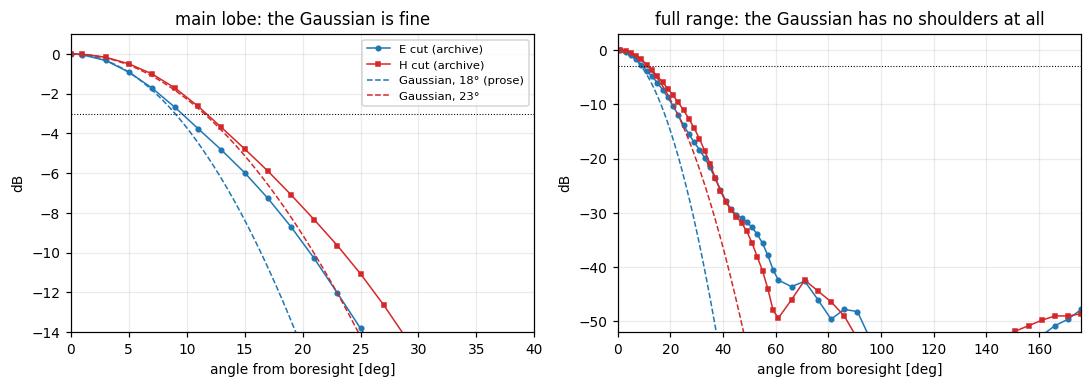

In [10]:
from limTOD.tris import approximate_tris_gaussian_beam_map, tris_cut_beam_response

e_fwhm, h_fwhm = cuts.half_power_full_width_deg()
half_power_db = -10 * np.log10(2)
print(f"measured from the archive table : E {e_fwhm:.3f} deg, H {h_fwhm:.3f} deg")
print(f"ring-header prose               : E 18 deg  ({100*(18/e_fwhm-1):+.1f} % vs the table)")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
fine = np.linspace(0, 60, 400)
for ax, span in zip(axes, [(0, 40, -14, 1), (0, 176, -52, 3)]):
    ax.plot(cuts.angle_deg, cuts.e_plane_db, "o-", ms=3, lw=1, color="tab:blue", label="E cut (archive)")
    ax.plot(cuts.angle_deg, cuts.h_plane_db, "s-", ms=3, lw=1, color="tab:red", label="H cut (archive)")
    ax.plot(fine, half_power_db * (2 * fine / 18.0) ** 2, "--", color="tab:blue", lw=1,
            label="Gaussian, 18° (prose)")
    ax.plot(fine, half_power_db * (2 * fine / 23.0) ** 2, "--", color="tab:red", lw=1,
            label="Gaussian, 23°")
    ax.axhline(half_power_db, color="k", lw=0.7, ls=":")
    ax.set_xlim(span[0], span[1]); ax.set_ylim(span[2], span[3])
    ax.set_xlabel("angle from boresight [deg]"); ax.set_ylabel("dB")
    ax.grid(alpha=0.25)
axes[0].legend(fontsize=7.5)
axes[0].set_title("main lobe: the Gaussian is fine")
axes[1].set_title("full range: the Gaussian has no shoulders at all")
fig.tight_layout()

`tris_cut_beam_map` builds a 2-D beam from these cuts by interpolating in $\theta$ and
blending in $\phi$ with $\cos^2\phi$ / $\sin^2\phi$ weights. The default `blend="db"` is
the exact generalization of an elliptical Gaussian — feed it Gaussian cuts and it
reproduces `approximate_tris_gaussian_beam_map` identically.

/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/healpy/visufunc.py:1630: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  ax.graticule(dpar=dpar, dmer=dmer, coord=coord, local=local, **kwds)


Text(0.5, 1.02, 'E plane runs left–right (φ=0/180), H plane up–down — before the −7° roll')

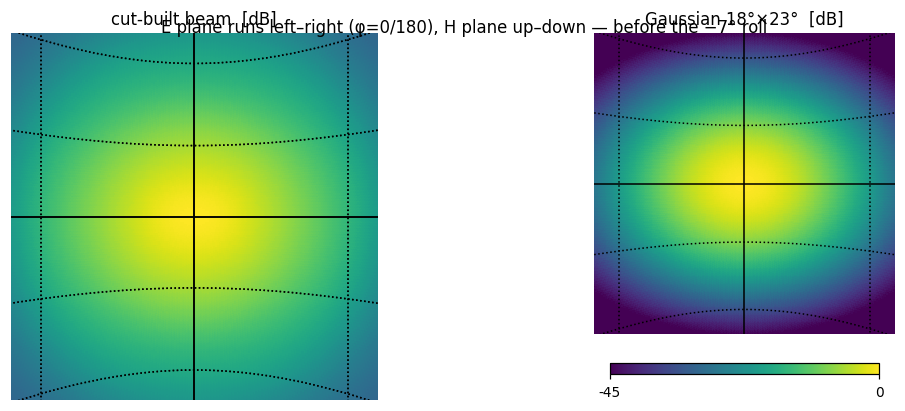

In [11]:
from limTOD.tris import tris_cut_beam_map, tris_horizon_mask

NSIDE_BEAM = 128
cut_beam = tris_cut_beam_map(cuts, nside=NSIDE_BEAM, normalization="peak")
gauss_beam = approximate_tris_gaussian_beam_map(nside=NSIDE_BEAM, normalization="peak")

fig = plt.figure(figsize=(10, 3.4))
for i, (m, title) in enumerate([(cut_beam, "cut-built beam"), (gauss_beam, "Gaussian 18°×23°")]):
    hp.gnomview(10 * np.log10(np.maximum(m, 1e-12)), rot=(0, 90), reso=14, xsize=340,
                min=-45, max=0, title=f"{title}  [dB]", sub=(1, 2, i + 1), notext=True,
                cbar=(i == 1), hold=False)
    hp.graticule(dpar=15, dmer=30, verbose=False)
plt.suptitle("E plane runs left–right (φ=0/180), H plane up–down — before the −7° roll", y=1.02)

In [12]:
theta = np.rad2deg(hp.pix2ang(NSIDE_BEAM, np.arange(hp.nside2npix(NSIDE_BEAM)))[0])
order = np.argsort(theta)
mask = tris_horizon_mask(NSIDE_BEAM)

rows = []
for name, beam in (("Gaussian 18/23", gauss_beam), ("archive cuts", cut_beam)):
    weight = beam / beam.sum()
    cumulative = np.cumsum(weight[order])
    rows.append((name, [cumulative[theta[order] < lim][-1] for lim in (10, 20, 30, 45)],
                 float(weight[mask == 0].sum())))

print(f"{'beam':<16}{'θ<10°':>9}{'θ<20°':>9}{'θ<30°':>9}{'θ<45°':>9}{'below horizon':>16}")
for name, cum, below in rows:
    print(f"{name:<16}" + "".join(f"{c:9.4f}" for c in cum) + f"{below:16.2e}")
print(f"\nGround pickup implied by the cuts at a 300 K ground: {rows[1][2]*300:.3f} K")
print(f"...the Gaussian says                                  {rows[0][2]*300:.3f} K")
print("The published zero-level systematic is 0.066 K, so this term is NOT negligible;")
print("that is why build_tris_mapmaking_inputs applies a horizon mask by default.")

beam                θ<10°    θ<20°    θ<30°    θ<45°   below horizon
Gaussian 18/23     0.4917   0.9260   0.9965   1.0000        2.77e-20
archive cuts       0.3809   0.8107   0.9660   0.9970        1.16e-04

Ground pickup implied by the cuts at a 300 K ground: 0.035 K
...the Gaussian says                                  0.000 K
The published zero-level systematic is 0.066 K, so this term is NOT negligible;
that is why build_tris_mapmaking_inputs applies a horizon mask by default.


---
## Part 3 — Forward-modelling real GSM through limTOD

TRIS is **absolutely** calibrated, so it can discriminate between sky models in a way
relative experiments cannot. We take GSM2008 and GSM2016 (both Galactic-only, CMB
monopole excluded), put them into the TRIS temperature convention, and push them through
`generate_TOD_sky` with the TRIS geometry, cut beam and horizon mask.

In [13]:
from pygdsm import GlobalSkyModel, GlobalSkyModel16
from limTOD import generate_TOD_sky
from limTOD.tris import to_tris_temperature_convention

NSIDE_SKY = 64
rotator = hp.Rotator(coord=["G", "C"])

def gsm_in_tris_convention(model, frequency_mhz, nside=NSIDE_SKY):
    # Galactic GSM map -> equatorial, RING, TRIS convention (RJ + CMB monopole)
    galactic = hp.ud_grade(model.generate(frequency_mhz), nside)
    return to_tris_temperature_convention(rotator.rotate_map_pixel(galactic), frequency_mhz)

# data_unit='TRJ': GSM2016 defaults to thermodynamic units. At 600 MHz that is only a
# 1e-5 effect, but TRIS is Rayleigh-Jeans so we ask for the matching convention.
MODELS = {"GSM2016": GlobalSkyModel16(data_unit="TRJ"), "GSM2008": GlobalSkyModel()}
sky_maps = {(name, ring.effective_frequency_mhz): gsm_in_tris_convention(model, ring.effective_frequency_mhz)
            for name, model in MODELS.items() for ring in (ring600, ring820)}
for key, m in sky_maps.items():
    print(f"{key[0]} @ {key[1]:6.1f} MHz : {m.min():7.2f} .. {m.max():8.1f} K  (median {np.median(m):6.2f})")

GSM2016 @  600.5 MHz :   10.28 ..    515.0 K  (median  14.72)
GSM2016 @  817.8 MHz :    8.16 ..    242.9 K  (median   9.95)
GSM2008 @  600.5 MHz :    6.00 ..    374.1 K  (median  10.83)
GSM2008 @  817.8 MHz :    4.14 ..    165.0 K  (median   6.23)


In [14]:
beam_sky = tris_cut_beam_map(cuts, nside=NSIDE_SKY, normalization="peak")
gauss_sky = approximate_tris_gaussian_beam_map(nside=NSIDE_SKY, normalization="peak")
horizon = tris_horizon_mask(NSIDE_SKY)

def tris_profile(sky_map, ring, beam):
    g = tris_zenith_geometry(ring.ra_deg)
    return generate_TOD_sky(beam, sky_map, g.lst_deg, g.latitude_deg, g.azimuth_deg,
                            g.elevation_deg, g.selfrot_deg, normalize_beam=True,
                            horizontal_mask=horizon)

profiles = {}
for ring in (ring600, ring820):
    nu = ring.effective_frequency_mhz
    for name in MODELS:
        profiles[(name, nu, "cut")] = tris_profile(sky_maps[(name, nu)], ring, beam_sky)
    profiles[("GSM2016", nu, "gauss")] = tris_profile(sky_maps[("GSM2016", nu)], ring, gauss_sky)
print("forward models computed:", len(profiles))

forward models computed: 6


  ν [MHz] model      mean offset  scatter rms   max |Δ|
    600.5 GSM2016         +1.889        0.650     2.796
    600.5 GSM2008         -1.919        0.476     3.946
    817.8 GSM2016         +3.098        0.300     3.533
    817.8 GSM2008         -0.563        0.271     1.427


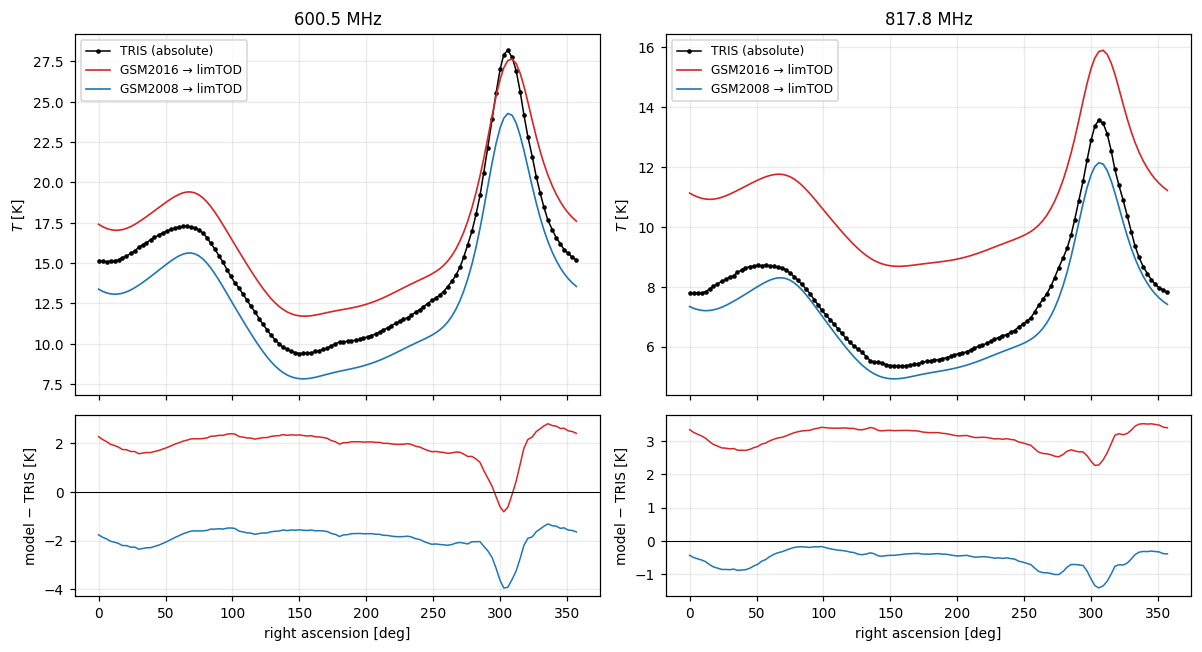

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex="col",
                         gridspec_kw={"height_ratios": [2, 1]})
summary = []
for col, ring in enumerate((ring600, ring820)):
    nu = ring.effective_frequency_mhz
    top, bot = axes[0, col], axes[1, col]
    top.plot(ring.ra_deg, ring.temperature_k, "k.-", ms=4, lw=1.0, label="TRIS (absolute)")
    for name, colour in (("GSM2016", "tab:red"), ("GSM2008", "tab:blue")):
        p = profiles[(name, nu, "cut")]
        top.plot(ring.ra_deg, p, lw=1.1, color=colour, label=f"{name} → limTOD")
        d = p - ring.temperature_k
        bot.plot(ring.ra_deg, d, lw=1.0, color=colour)
        summary.append((nu, name, d.mean(), d.std(), np.abs(d).max()))
    bot.axhline(0, color="k", lw=0.7)
    top.set_ylabel("$T$ [K]"); bot.set_ylabel("model − TRIS [K]")
    bot.set_xlabel("right ascension [deg]")
    top.set_title(f"{nu:.1f} MHz"); top.legend(fontsize=8); top.grid(alpha=0.25); bot.grid(alpha=0.25)
fig.tight_layout()

print(f"{'ν [MHz]':>9} {'model':<9}{'mean offset':>13}{'scatter rms':>13}{'max |Δ|':>10}")
for nu, name, mean, rms, mx in summary:
    print(f"{nu:9.1f} {name:<9}{mean:+13.3f}{rms:13.3f}{mx:10.3f}")

**The two GSM versions bracket TRIS.** GSM2016 is systematically hot by ~1.9 K at
600 MHz and ~3.1 K at 820 MHz; GSM2008 is cold by ~1.9 K and ~0.6 K. Since TRIS is
absolutely calibrated and its zero-level systematic is only 0.066 K (600 MHz), these
offsets are real model discrepancies, tens of times larger than anything instrumental.

The *shape* agreement is much better than the *level* agreement — the residual scatter
after removing the mean is 0.27–0.65 K. That is the useful part: TRIS constrains the
zero point of a sky model far more tightly than the model's own calibration.

### How much does the beam choice matter here?

cut-built beam vs Gaussian, same sky: rms 0.631 K, max 2.168 K
  ... against a median statistical error of 0.010 K (63x)
  ... and a zero-level systematic of 0.066 K (10x)


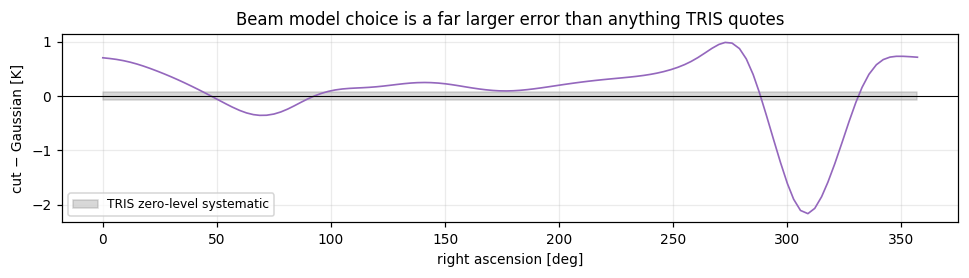

In [16]:
nu = ring600.effective_frequency_mhz
delta_beam = profiles[("GSM2016", nu, "cut")] - profiles[("GSM2016", nu, "gauss")]
print(f"cut-built beam vs Gaussian, same sky: rms {delta_beam.std():.3f} K, "
      f"max {np.abs(delta_beam).max():.3f} K")
print(f"  ... against a median statistical error of {np.median(ring600.statistical_uncertainty_k):.3f} K "
      f"({delta_beam.std()/np.median(ring600.statistical_uncertainty_k):.0f}x)")
print(f"  ... and a zero-level systematic of {ring600.zero_level_uncertainty_k:.3f} K "
      f"({delta_beam.std()/ring600.zero_level_uncertainty_k:.0f}x)")

fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(ring600.ra_deg, delta_beam, lw=1.1, color="tab:purple")
ax.axhline(0, color="k", lw=0.7)
ax.fill_between(ring600.ra_deg, -ring600.zero_level_uncertainty_k, ring600.zero_level_uncertainty_k,
                color="grey", alpha=0.3, label="TRIS zero-level systematic")
ax.set_xlabel("right ascension [deg]"); ax.set_ylabel("cut − Gaussian [K]")
ax.legend(fontsize=8); ax.grid(alpha=0.25)
ax.set_title("Beam model choice is a far larger error than anything TRIS quotes")
fig.tight_layout()

---
## Part 4 — Prior-regularized map-making

### Pixelisation: ~3 pixels per beam FWHM

The beam is 19.2° × 23.4°. `nside=8` gives 7.33° pixels, i.e. **2.6 pixels across the
narrow (E) axis and 3.2 across the wide (H) axis** — the requested sampling. Going finer
does not add information: a 120-sample ring measures roughly 15 independent numbers,
because the beam suppresses harmonics above $m \sim 8$.

In [17]:
from limTOD.tris import build_tris_mapmaking_inputs, tris_prior_from_template

NSIDE_MAP = 8
pixel_deg = hp.nside2resol(NSIDE_MAP, arcmin=True) / 60
print(f"nside={NSIDE_MAP}: pixel {pixel_deg:.2f} deg")
print(f"  E FWHM / pixel = {e_fwhm/pixel_deg:.2f}     H FWHM / pixel = {h_fwhm/pixel_deg:.2f}")

inputs = build_tris_mapmaking_inputs(
    ring600, nside=NSIDE_MAP, cuts=cuts,
    dec_half_width_deg=45.0,
    uncertainty_floor_k=float(ring600.statistical_uncertainty_k[
        ring600.statistical_uncertainty_k > 0].min()),
    zero_level_sigma_k=float(ring600.zero_level_uncertainty_k),
    nside_hires=NSIDE_SKY,      # rotate the beam at high resolution, sample at nside=8
)
print(f"\noperator {inputs.operator.shape}  ({inputs.sky_parameter_count} sky pixels "
      f"+ {'1 zero-level' if inputs.has_zero_level else 'no'} nuisance)")
print(f"beam coverage retained by the ±45° band: {inputs.beam_coverage.min():.5f}")
print(f"monopole degeneracy (1 = exactly degenerate): {inputs.monopole_degeneracy:.12f}")

nside=8: pixel 7.33 deg
  E FWHM / pixel = 2.61     H FWHM / pixel = 3.19



operator (120, 401)  (400 sky pixels + 1 zero-level nuisance)
beam coverage retained by the ±45° band: 0.99878
monopole degeneracy (1 = exactly degenerate): 0.999999954562


That degeneracy number is the headline caveat: the zero-level column is all ones, and the
sky monopole's response `A @ 1` is `beam_coverage`, which is constant for a normalized
beam on a zenith drift scan. **A free zero level and a free sky monopole are not
separately measurable from one ring** — the split is set by the priors.

### The prior

We use GSM2008 (the closer of the two at 600 MHz) as the template, with a 10 % relative
width plus a 0.3 K floor. `implied_monopole_prior_sigma_k` says whether the fitted zero
level can be believed.

In [18]:
template_full = hp.ud_grade(sky_maps[("GSM2008", nu)], NSIDE_MAP)
prior_mean, prior_sigma = tris_prior_from_template(
    template_full, inputs.pixel_indices, relative_sigma=0.10, absolute_sigma_k=0.3)

implied = inputs.implied_monopole_prior_sigma_k(prior_sigma)
print(f"per-pixel prior sigma : median {np.median(prior_sigma):.3f} K")
print(f"implied monopole prior: {implied:.4f} K")
print(f"zero-level prior      : {inputs.zero_level_sigma_k:.4f} K")
print("=> " + ("sky monopole is much tighter, the fitted offset is meaningful"
      if implied < 0.3 * inputs.zero_level_sigma_k else
      "COMPARABLE: the offset/monopole split is prior-driven, treat the fitted offset with care"))

per-pixel prior sigma : median 1.156 K
implied monopole prior: 0.1106 K
zero-level prior      : 0.0660 K
=> COMPARABLE: the offset/monopole split is prior-driven, treat the fitted offset with care


### Closure test — and the trap it exposes

Simulate a ring from GSM2016 plus a known 0.03 K offset, then solve twice:

* with an **unbiased** prior (centred on the truth, loosely), and
* with a **biased** prior (centred on GSM2008 — Part 3 measured the two models ~3.8 K
  apart, so this is the realistic situation).

Watch the fitted zero level and the reduced chi-square together.

In [19]:
truth = hp.ud_grade(sky_maps[("GSM2016", nu)], NSIDE_MAP)[inputs.pixel_indices]
true_offset = 0.03
rng = np.random.default_rng(0)
simulated = inputs.with_data(
    inputs.predict(truth, true_offset) + rng.normal(0, inputs.noise.statistical_sigma_k))
sky_op = inputs.operator[:, :inputs.sky_parameter_count]

unbiased_template = np.array(template_full)
unbiased_template[inputs.pixel_indices] = truth * (1 + 0.05 * rng.standard_normal(truth.size))

for label, template in (("unbiased prior (centred on truth)", unbiased_template),
                        ("biased prior (GSM2008, truth is GSM2016)", template_full)):
    mean_p, sigma_p = tris_prior_from_template(
        template, inputs.pixel_indices, relative_sigma=0.05, absolute_sigma_k=0.1)
    implied = inputs.implied_monopole_prior_sigma_k(sigma_p)
    fit = simulated.solve(prior_map=mean_p, prior_sigma_k=sigma_p)
    print(f"--- {label}")
    print(f"      implied monopole prior {implied:.4f} K  vs  zero-level prior "
          f"{inputs.zero_level_sigma_k:.4f} K   (ratio {implied/inputs.zero_level_sigma_k:.2f})")
    print(f"      prior bias at the band mean   {np.mean(mean_p - truth):+8.4f} K")
    print(f"      fitted zero level             {fit.zero_level_k:+8.4f} ± "
          f"{fit.zero_level_uncertainty_k:.4f} K      (true {true_offset:+.4f})")
    print(f"      reduced chi-square            {fit.reduced_chi_square:8.3f}")
    print(f"      beam-convolved error rms   prior {np.std(sky_op @ (mean_p - truth)):.4f}"
          f"  ->  posterior {np.std(sky_op @ (fit.sky_k - truth)):.4f} K")
    print(f"      per-pixel error rms        prior {np.std(mean_p - truth):.4f}"
          f"  ->  posterior {np.std(fit.sky_k - truth):.4f} K")

--- unbiased prior (centred on truth)
      implied monopole prior 0.0677 K  vs  zero-level prior 0.0660 K   (ratio 1.03)
      prior bias at the band mean    -0.0439 K
      fitted zero level              +0.0807 ± 0.0425 K      (true +0.0300)
      reduced chi-square               0.154
      beam-convolved error rms   prior 0.1397  ->  posterior 0.0098 K
      per-pixel error rms        prior 0.9867  ->  posterior 0.8038 K
--- biased prior (GSM2008, truth is GSM2016)
      implied monopole prior 0.0547 K  vs  zero-level prior 0.0660 K   (ratio 0.83)
      prior bias at the band mean    -3.8625 K
      fitted zero level              +2.8127 ± 0.0346 K      (true +0.0300)
      reduced chi-square               0.202
      beam-convolved error rms   prior 0.2283  ->  posterior 0.0094 K
      per-pixel error rms        prior 1.0969  ->  posterior 0.6066 K


Both fits pin the **measured** direction — the beam-convolved sky — to the noise level,
a ~20× improvement on the prior. That part always works.

The zero level is where it gets interesting. With an unbiased prior it is recovered.
With a biased one the fit hands the entire ~3.8 K model discrepancy to the nuisance
offset — **and the reduced chi-square still looks healthy**, because a 401-parameter
model with an informative prior can absorb almost anything. The offset lands many prior-σ
from its own prior mean without any warning from the fit quality alone.

So `implied_monopole_prior_sigma_k` being small is *necessary but not sufficient*. The
prior must also be **unbiased at the monopole**, which is precisely the quantity a single
absolutely-calibrated ring was supposed to supply. There is no bootstrap here: you cannot
extract an absolute zero point from one ring plus a sky model whose own absolute scale you
do not already trust. What you *can* do is measure their difference — which is exactly the
GSM comparison in Part 3, and is a real result.

In [20]:
solution = inputs.solve(prior_map=prior_mean, prior_sigma_k=prior_sigma)
pull = solution.zero_level_k / inputs.zero_level_sigma_k
print(f"reduced chi-square   {solution.reduced_chi_square:.2f}")
print(f"fitted zero level    {solution.zero_level_k:+.4f} ± {solution.zero_level_uncertainty_k:.4f} K")
print(f"  ... that is {pull:+.1f} prior-sigma away from the 0.066 K prior mean of zero")
print(f"residual rms         {solution.residual_k.std():.4f} K")
if solution.reduced_chi_square > 3:
    print("\n>> chi-square >> 1: the template, not the noise, dominates the residual.")
    print("   The fitted 'zero level' is absorbing GSM's overall offset (Part 3 measured")
    print("   GSM2008 as ~1.9 K cold at 600 MHz), so read it as a model-mismatch amplitude,")
    print("   NOT as a measurement of the archive's zero point.")

reduced chi-square   6.53
fitted zero level    +0.7245 ± 0.0517 K
  ... that is +11.0 prior-sigma away from the 0.066 K prior mean of zero
residual rms         0.0414 K

>> chi-square >> 1: the template, not the noise, dominates the residual.
   The fitted 'zero level' is absorbing GSM's overall offset (Part 3 measured
   GSM2008 as ~1.9 K cold at 600 MHz), so read it as a model-mismatch amplitude,
   NOT as a measurement of the archive's zero point.


### Prior vs posterior, side by side

The solved region is a declination band, so a Mollweide projection would spend half
its area on sky that was never fitted. These panels project just the band, keeping
HEALPix pixel boundaries (`interpolation="nearest"`), with grey for pixels outside it.
Prior and posterior share a colour scale in each row so the comparison is honest.

σ shrinkage: min 0.220, median 0.945, max 1.000
pixels whose σ shrank by >5%: 201 / 400
z-score over the 326/400 pixels where the data resolved >5% of the prior width:
   mean +0.69   std 5.93   |z|>3 in 41% of pixels (N(0,1) would give 0.3%)


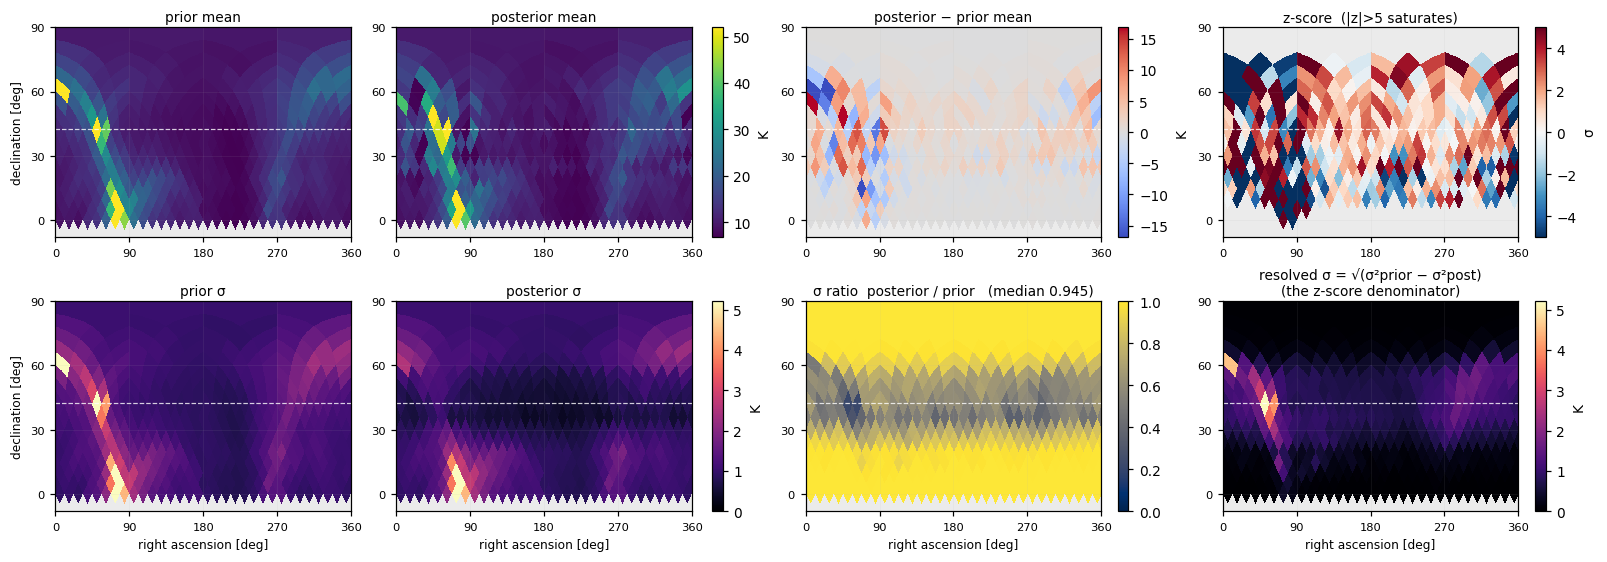

In [21]:
LATRA, LONRA = [-8, 90], [-180, 180]
EXTENT = [LONRA[0], LONRA[1], LATRA[0], LATRA[1]]

def band_image(values, pixel_indices=None, nside=None):
    # project the solved declination band with healpy, draw it with matplotlib
    nside = nside or NSIDE_MAP
    pixel_indices = inputs.pixel_indices if pixel_indices is None else pixel_indices
    full = np.full(hp.nside2npix(nside), np.nan)
    full[pixel_indices] = values
    img = hp.cartview(full, lonra=LONRA, latra=LATRA, rot=[180, 0, 0], xsize=1400,
                      return_projected_map=True, hold=False)
    plt.close()
    return np.asarray(img)

def show_band(ax, values, cmap, title, mark_boresight=True, **kw):
    im = ax.imshow(band_image(values), origin="lower", extent=EXTENT, aspect="auto",
                   cmap=cmap, interpolation="nearest", **kw)
    ax.set_title(title, fontsize=9, pad=4)
    ax.set_xticks([-180, -90, 0, 90, 180])
    ax.set_xticklabels(["0", "90", "180", "270", "360"])
    ax.set_yticks([0, 30, 60, 90])
    ax.tick_params(labelsize=7.5)
    ax.set_facecolor("0.92")
    if mark_boresight:
        ax.axhline(inputs.geometry.boresight_dec_deg, color="w", lw=0.8, ls="--", alpha=0.8)
    ax.grid(alpha=0.15, lw=0.4)
    return im

def prior_to_posterior_z(prior_mean, prior_sigma, post_mean, post_sigma,
                         min_resolved_frac=0.05):
    # For a linear-Gaussian model the shift of the posterior mean away from the
    # prior mean has covariance S - Sigma exactly, so per pixel the standardizing
    # width is sqrt(sigma_prior^2 - sigma_post^2): the variance the data actually
    # resolved. Dividing by sigma_prior instead understates the tension.
    resolved_sigma = np.sqrt(np.maximum(prior_sigma**2 - post_sigma**2, 0.0))
    usable = resolved_sigma > min_resolved_frac * prior_sigma
    z = np.full(np.shape(prior_mean), np.nan)
    z[usable] = (post_mean - prior_mean)[usable] / resolved_sigma[usable]
    return z, resolved_sigma, usable

z_map, resolved_sigma, usable = prior_to_posterior_z(
    prior_mean, prior_sigma, solution.sky_k, solution.sky_uncertainty_k)
ZLIM = 5.0

fig, axes = plt.subplots(2, 4, figsize=(14.5, 5.0), constrained_layout=True)

lo, hi = np.percentile(prior_mean, [1, 99])
im_mean = show_band(axes[0, 0], prior_mean, "viridis", "prior mean", vmin=lo, vmax=hi)
show_band(axes[0, 1], solution.sky_k, "viridis", "posterior mean", vmin=lo, vmax=hi)
change = solution.sky_k - prior_mean
lim = np.percentile(np.abs(change), 99)
im_diff = show_band(axes[0, 2], change, "coolwarm", "posterior − prior mean",
                    vmin=-lim, vmax=lim)
im_z = show_band(axes[0, 3], z_map, "RdBu_r",
                 f"z-score  (|z|>{ZLIM:.0f} saturates)", vmin=-ZLIM, vmax=ZLIM)

shi = np.percentile(prior_sigma, 99)
im_sig = show_band(axes[1, 0], prior_sigma, "magma", "prior σ", vmin=0.0, vmax=shi)
show_band(axes[1, 1], solution.sky_uncertainty_k, "magma", "posterior σ", vmin=0.0, vmax=shi)
shrink = solution.sky_uncertainty_k / prior_sigma
im_rat = show_band(axes[1, 2], shrink, "cividis",
                   f"σ ratio  posterior / prior   (median {np.median(shrink):.3f})",
                   vmin=0.0, vmax=1.0)
im_res = show_band(axes[1, 3], resolved_sigma, "magma",
                   "resolved σ = √(σ²prior − σ²post)\n(the z-score denominator)",
                   vmin=0.0, vmax=shi)

fig.colorbar(im_mean, ax=list(axes[0, :2]), fraction=0.030, pad=0.015, label="K")
fig.colorbar(im_diff, ax=axes[0, 2], fraction=0.046, pad=0.02, label="K")
fig.colorbar(im_z, ax=axes[0, 3], fraction=0.046, pad=0.02, label="σ")
fig.colorbar(im_sig, ax=list(axes[1, :2]), fraction=0.030, pad=0.015, label="K")
fig.colorbar(im_rat, ax=axes[1, 2], fraction=0.046, pad=0.02)
fig.colorbar(im_res, ax=axes[1, 3], fraction=0.046, pad=0.02, label="K")
for ax in axes[1]:
    ax.set_xlabel("right ascension [deg]", fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("declination [deg]", fontsize=8)

finite_z = z_map[np.isfinite(z_map)]
print(f"σ shrinkage: min {shrink.min():.3f}, median {np.median(shrink):.3f}, "
      f"max {shrink.max():.3f}")
print(f"pixels whose σ shrank by >5%: {int((shrink < 0.95).sum())} / {shrink.size}")
print(f"z-score over the {finite_z.size}/{z_map.size} pixels where the data resolved "
      f">5% of the prior width:")
print(f"   mean {finite_z.mean():+.2f}   std {finite_z.std():.2f}   "
      f"|z|>3 in {100*np.mean(np.abs(finite_z) > 3):.0f}% of pixels "
      f"(N(0,1) would give 0.3%)")

Text(0.5, 1.0, '|z| dips where the beam dwelt —\nthere the data resolved more variance')

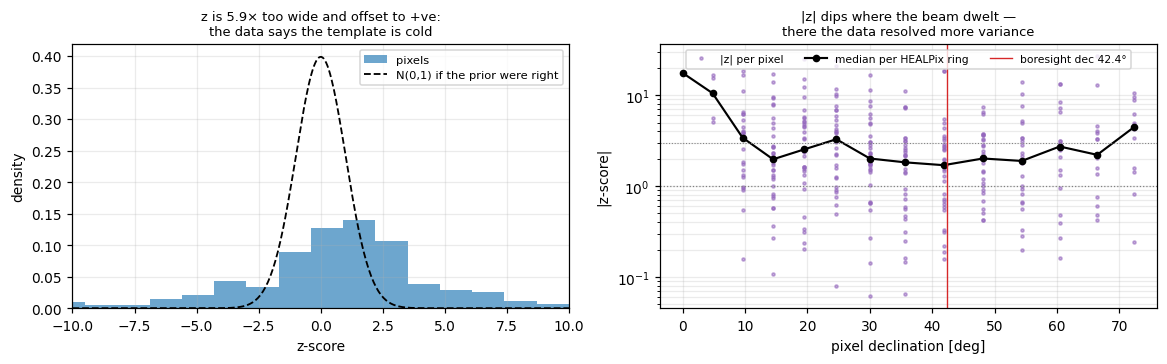

In [22]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.2), constrained_layout=True)

ax = axes[0]
ax.hist(finite_z, bins=40, density=True, alpha=0.65, color="tab:blue", label="pixels")
grid = np.linspace(-ZLIM * 2, ZLIM * 2, 400)
ax.plot(grid, norm.pdf(grid), "k--", lw=1.2, label="N(0,1) if the prior were right")
ax.set_xlim(-ZLIM * 2, ZLIM * 2)
ax.set_xlabel("z-score"); ax.set_ylabel("density"); ax.legend(fontsize=7.5)
ax.grid(alpha=0.25)
ax.set_title(f"z is {finite_z.std():.1f}× too wide and offset to +ve:\n"
             "the data says the template is cold", fontsize=8.5)

ax = axes[1]
dec_pix = 90 - np.rad2deg(hp.pix2ang(NSIDE_MAP, inputs.pixel_indices)[0])
ax.plot(dec_pix[usable], np.abs(z_map[usable]), ".", ms=4, color="tab:purple", alpha=0.55,
        label="|z| per pixel")
rings = np.unique(np.round(dec_pix[usable], 3))
ring_median = np.array([np.median(np.abs(z_map[usable][np.round(dec_pix[usable], 3) == r]))
                        for r in rings])
ax.plot(rings, ring_median, "o-", ms=4, lw=1.4, color="k", label="median per HEALPix ring")
ax.axhline(1.0, color="grey", lw=0.8, ls=":")
ax.axhline(3.0, color="grey", lw=0.7, ls=":")
ax.axvline(inputs.geometry.boresight_dec_deg, color="tab:red", lw=0.9,
           label=f"boresight dec {inputs.geometry.boresight_dec_deg:.1f}°")
ax.set_yscale("log")
ax.set_xlabel("pixel declination [deg]"); ax.set_ylabel("|z-score|")
ax.legend(fontsize=7, loc="upper center", ncol=3); ax.grid(alpha=0.25, which="both")
ax.set_title("|z| dips where the beam dwelt —\nthere the data resolved more variance",
             fontsize=8.5)

The bottom row is the honest one. The posterior σ is barely below the prior σ over most
of the band — a median ratio near 0.95 — and what shrinkage there is concentrates around
the boresight declination (dashed line), which is exactly where the beam spent its time.
120 samples cannot tighten 400 pixels; the map you see is mostly the prior, redisplayed.

The **z-score** panel is the one that shows whether that redisplay is *consistent*. For a
linear-Gaussian model the shift of the posterior mean away from the prior mean has
covariance exactly `S − Σ`, so the right standardizing width per pixel is
`√(σ²prior − σ²post)` — the variance the data actually resolved, plotted underneath it.
If the prior were correct, this map would be N(0,1) noise. It is not: the spread is ~6σ,
skewed positive, so the ring is systematically pulling the map **up** away from GSM2008 —
the same 1.9 K deficit Part 3 measured, now resolved spatially.

Grey in the z panel means something different from grey elsewhere: those are pixels where
the data resolved less than 5 % of the prior width, so the denominator is consistent with
zero and z carries no information. They are excluded rather than plotted as huge numbers.

Dividing by `σprior` instead would be the intuitive choice and it is wrong: it understates
the spread by roughly 2.5× here, because most of the prior width was never resolved.

### Trying different prior strengths

If the prior is doing that much work, its strength is a knob worth turning. We sweep the
relative width from 30 % of the local sky brightness down to 1 %, and watch three things
together: the fitted zero level, the reduced chi-square, and how far the posterior σ
falls below the prior σ.

In [23]:
STRENGTHS = [(0.30, 1.0), (0.10, 0.3), (0.03, 0.1), (0.01, 0.03)]
scan = []
for rel, absol in STRENGTHS:
    mean_p, sigma_p = tris_prior_from_template(
        template_full, inputs.pixel_indices, relative_sigma=rel, absolute_sigma_k=absol)
    sol = inputs.solve(prior_map=mean_p, prior_sigma_k=sigma_p)
    scan.append(dict(rel=rel, absol=absol, prior_mean=mean_p, prior_sigma=sigma_p,
                     sol=sol, implied=inputs.implied_monopole_prior_sigma_k(sigma_p)))

# Part 3 measured how cold GSM2008 runs at this frequency; reuse that number.
gsm2008_deficit = -[mean for (f, n, mean, _r, _m) in summary if n == "GSM2008" and f == nu][0]

for row in scan:
    row["z"], _res, row["usable"] = prior_to_posterior_z(
        row["prior_mean"], row["prior_sigma"],
        row["sol"].sky_k, row["sol"].sky_uncertainty_k)

print(f"{'prior σ':>9}{'implied monopole σ':>21}{'zero level [K]':>22}"
      f"{'red. χ²':>10}{'shrinkage':>11}{'z std':>8}{'|z|>3':>8}")
for row in scan:
    sol, zf = row["sol"], row["z"][np.isfinite(row["z"])]
    print(f"{row['rel']*100:7.0f}% {row['implied']:20.4f} "
          f"{sol.zero_level_k:+13.4f} ± {sol.zero_level_uncertainty_k:.4f} "
          f"{sol.reduced_chi_square:9.2f} "
          f"{np.median(sol.sky_uncertainty_k / row['prior_sigma']):10.3f} "
          f"{zf.std():7.1f} {100*np.mean(np.abs(zf) > 3):6.0f}%")
print(f"\nfor reference, Part 3 measured GSM2008 as {gsm2008_deficit:.2f} K cold at "
      f"{nu:.1f} MHz")

  prior σ   implied monopole σ        zero level [K]   red. χ²  shrinkage   z std   |z|>3
     30%               0.3335       +0.1241 ± 0.0638      0.19      0.933     2.6     15%
     10%               0.1106       +0.7245 ± 0.0517      6.53      0.945     5.9     41%
      3%               0.0333       +1.5539 ± 0.0238     48.96      0.973    10.2     55%
      1%               0.0111       +1.7018 ± 0.0085    171.02      0.992    16.8     75%

for reference, Part 3 measured GSM2008 as 1.92 K cold at 600.5 MHz


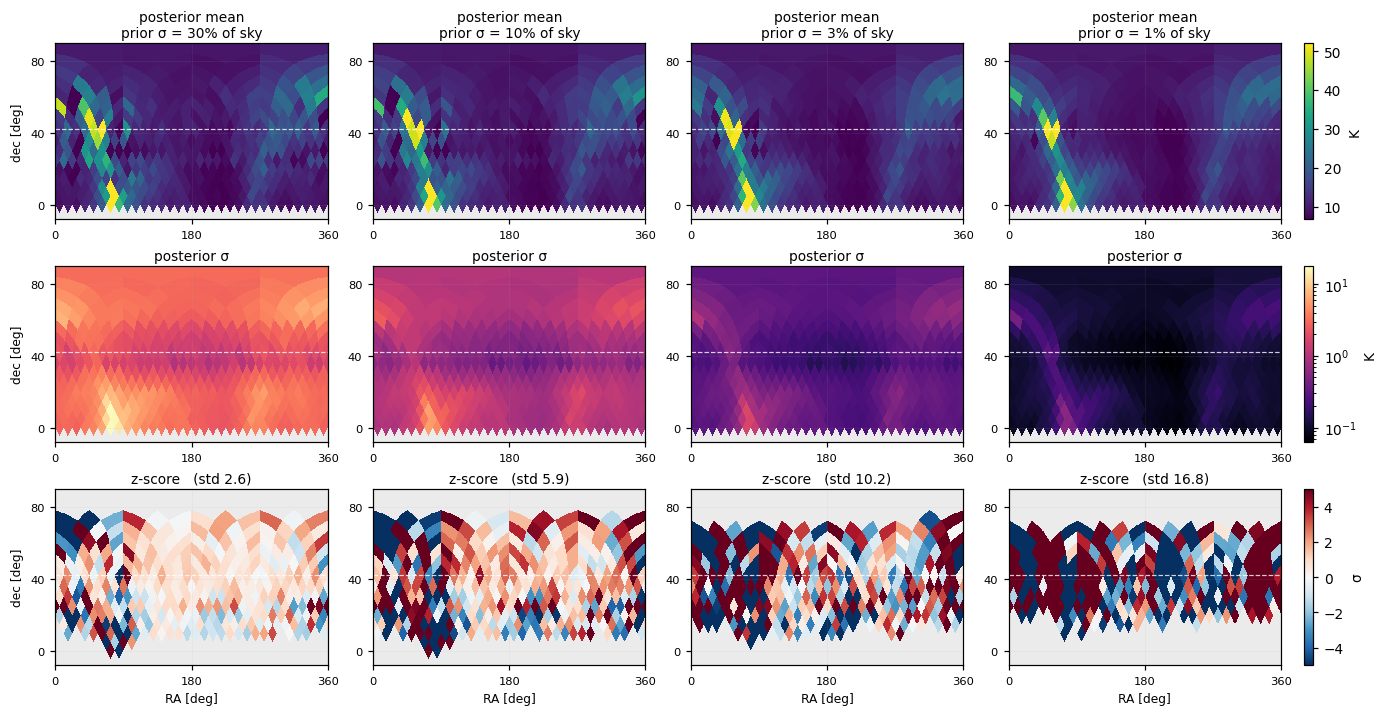

In [24]:
fig, axes = plt.subplots(3, len(scan), figsize=(12.5, 6.4), constrained_layout=True)
lo, hi = np.percentile(scan[1]["prior_mean"], [1, 99])
smin = min(np.min(r["sol"].sky_uncertainty_k) for r in scan)
smax = max(np.max(r["prior_sigma"]) for r in scan)
for j, row in enumerate(scan):
    im_m = show_band(axes[0, j], row["sol"].sky_k, "viridis",
                     f"posterior mean\nprior σ = {row['rel']*100:.0f}% of sky",
                     vmin=lo, vmax=hi)
    im_s = show_band(axes[1, j], row["sol"].sky_uncertainty_k, "magma", "posterior σ",
                     norm=LogNorm(vmin=max(smin, 1e-3), vmax=smax))
    im_z = show_band(axes[2, j], row["z"], "RdBu_r",
                     f"z-score   (std {row['z'][np.isfinite(row['z'])].std():.1f})",
                     vmin=-ZLIM, vmax=ZLIM)
    for ax in axes[:, j]:
        ax.set_yticks([0, 40, 80])
        ax.set_xticks([-180, 0, 180]); ax.set_xticklabels(["0", "180", "360"])
fig.colorbar(im_m, ax=list(axes[0]), fraction=0.020, pad=0.01, label="K")
fig.colorbar(im_s, ax=list(axes[1]), fraction=0.020, pad=0.01, label="K")
fig.colorbar(im_z, ax=list(axes[2]), fraction=0.020, pad=0.01, label="σ")
for ax in axes[2]:
    ax.set_xlabel("RA [deg]", fontsize=8)
for r in range(3):
    axes[r, 0].set_ylabel("dec [deg]", fontsize=8)

Text(0.5, 1.0, 'map-space tension grows the same way\nas the data-space chi-square')

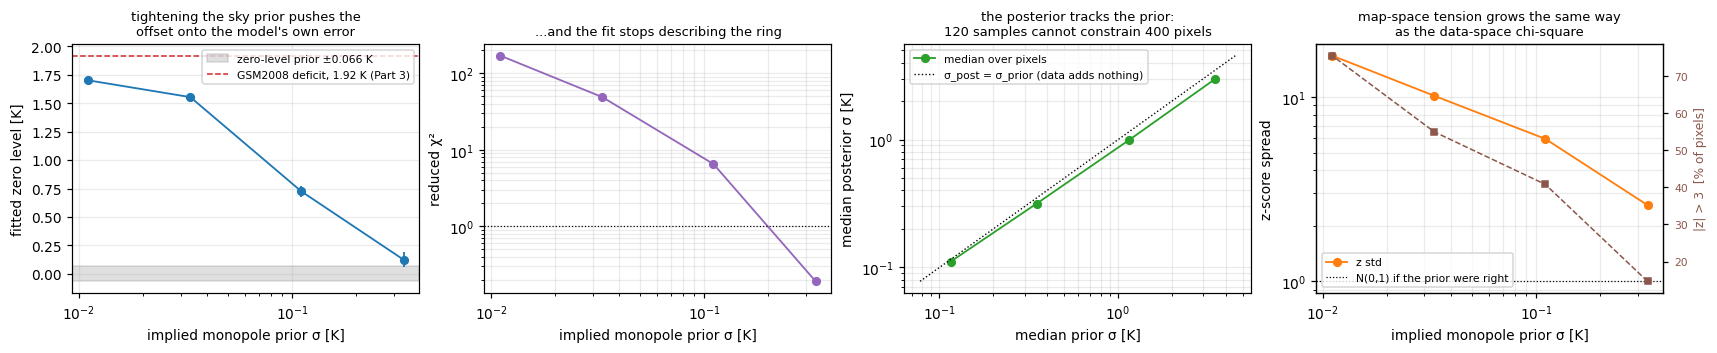

In [25]:
implied = np.array([r["implied"] for r in scan])
zero = np.array([r["sol"].zero_level_k for r in scan])
zerr = np.array([r["sol"].zero_level_uncertainty_k for r in scan])
chi2 = np.array([r["sol"].reduced_chi_square for r in scan])
sig_prior = np.array([np.median(r["prior_sigma"]) for r in scan])
sig_post = np.array([np.median(r["sol"].sky_uncertainty_k) for r in scan])

fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.1), constrained_layout=True)

ax = axes[0]
ax.axhspan(-inputs.zero_level_sigma_k, inputs.zero_level_sigma_k, color="grey",
           alpha=0.25, label=f"zero-level prior ±{inputs.zero_level_sigma_k:.3f} K")
ax.axhline(gsm2008_deficit, color="tab:red", ls="--", lw=1,
           label=f"GSM2008 deficit, {gsm2008_deficit:.2f} K (Part 3)")
ax.errorbar(implied, zero, yerr=zerr, fmt="o-", ms=5, lw=1.2, color="tab:blue")
ax.set_xscale("log"); ax.set_xlabel("implied monopole prior σ [K]")
ax.set_ylabel("fitted zero level [K]"); ax.legend(fontsize=7); ax.grid(alpha=0.25)
ax.set_title("tightening the sky prior pushes the\noffset onto the model's own error",
             fontsize=8.5)

ax = axes[1]
ax.loglog(implied, chi2, "o-", ms=5, lw=1.2, color="tab:purple")
ax.axhline(1.0, color="k", lw=0.8, ls=":")
ax.set_xlabel("implied monopole prior σ [K]"); ax.set_ylabel("reduced χ²")
ax.grid(alpha=0.25, which="both")
ax.set_title("...and the fit stops describing the ring", fontsize=8.5)

ax = axes[2]
ax.loglog(sig_prior, sig_post, "o-", ms=5, lw=1.2, color="tab:green",
          label="median over pixels")
edge = np.array([sig_post.min() * 0.7, sig_prior.max() * 1.3])
ax.plot(edge, edge, "k:", lw=0.9, label="σ_post = σ_prior (data adds nothing)")
ax.set_xlabel("median prior σ [K]"); ax.set_ylabel("median posterior σ [K]")
ax.legend(fontsize=7); ax.grid(alpha=0.25, which="both")
ax.set_title("the posterior tracks the prior:\n120 samples cannot constrain 400 pixels",
             fontsize=8.5)

ax = axes[3]
z_std = np.array([r["z"][np.isfinite(r["z"])].std() for r in scan])
z_tail = np.array([100 * np.mean(np.abs(r["z"][np.isfinite(r["z"])]) > 3) for r in scan])
ax.loglog(implied, z_std, "o-", ms=5, lw=1.2, color="tab:orange", label="z std")
ax.axhline(1.0, color="k", lw=0.8, ls=":", label="N(0,1) if the prior were right")
twin = ax.twinx()
twin.semilogx(implied, z_tail, "s--", ms=4, lw=1.0, color="tab:brown")
twin.set_ylabel("|z| > 3  [% of pixels]", fontsize=8, color="tab:brown")
twin.tick_params(axis="y", labelcolor="tab:brown", labelsize=7)
ax.set_xlabel("implied monopole prior σ [K]"); ax.set_ylabel("z-score spread")
ax.legend(fontsize=7, loc="lower left"); ax.grid(alpha=0.25, which="both")
ax.set_title("map-space tension grows the same way\nas the data-space chi-square", fontsize=8.5)

The three curves say the same thing from different directions, and none of them is
flattering:

* **Left** — the fitted zero level is not a stable number. It slides from +0.12 K to
  +1.70 K as the prior tightens, heading straight for the ~1.9 K deficit Part 3 measured
  in GSM2008 itself. A tight prior forbids the map from moving, so the offset is the only
  place the model error can go.
* **Middle** — meanwhile the reduced chi-square climbs from 0.19 to ~170. There is no
  prior strength at which the offset looks small *and* the fit describes the ring. That
  is the signature of a misspecified model, not of a badly chosen prior.
* **Third** — the posterior σ tracks the prior σ almost one-to-one (median per-pixel
  shrinkage 0.93–0.99, and *rising* toward 1 as the prior tightens).
* **Right** — the z-score spread grows from ~2.6σ to ~17σ and the fraction of pixels
  beyond 3σ from 15 % to 76 %, tracking the chi-square. Data-space and map-space tension
  are the same statement seen from two sides, and neither is fixable by retuning the prior.
  Loosening the prior does not buy information; it just widens both.

The useful reading: with one ring and a template that is 1.9 K off, the honest product is
the *difference* measured in Part 3, not a map. A map becomes meaningful when the prior is
trustworthy at the monopole — from an independently calibrated model, or from combining
several rings and experiments.

---
## Summary

* The convention translation is verified numerically, not assumed: boresight at
  `(RA=LST, dec=lat)`, E plane on the meridian rolled `+7°` east by `selfrot=−7`, and
  TRIS temperatures in Rayleigh–Jeans **including** the CMB monopole.
* The beam must come from the archive's own cuts. The Gaussian differs by ~0.6 K rms on a
  real GSM sky — 60× the statistical error — and it throws away the below-horizon
  response entirely.
* TRIS's absolute calibration brackets the two GSM versions: GSM2016 runs ~1.9–3.1 K hot,
  GSM2008 ~0.6–1.9 K cold, with 0.3–0.7 K shape agreement.
* Map-making works, and the diagnostics are the point. `beam_coverage` says what the
  pixel band dropped; `monopole_degeneracy` (≈1) says a free zero level cannot be
  separated from the sky monopole; `reduced_chi_square` says whether the template can
  describe the ring at all. On real data with a GSM prior it cannot — which is a
  measurement of GSM, not a failure of the map-maker.

**Next**: an informative, well-calibrated template (or several rings / experiments jointly)
is what turns this from "prior redisplayed" into a measurement.